In [18]:
# Import library dasar untuk manipulasi data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk preprocessing dan modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Pengaturan visualisasi agar terlihat rapi
%matplotlib inline
sns.set_style('whitegrid')

In [19]:
# Membaca file dataset yang sudah diunggah ke Google Colab
df = pd.read_csv('Student Depression Dataset.csv')

# Menampilkan 5 baris pertama data
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [20]:
# Melihat informasi umum tentang dataset (jumlah kolom, baris, tipe data)
print("=== Informasi Dataset ===")
df.info()

# Membersihkan spasi pada nama kolom (jika ada) agar tidak error saat dipanggil
df.columns = df.columns.str.strip()

# Melihat statistik deskriptif untuk kolom numerik
print("\n=== Statistik Deskriptif ===")
display(df.describe())

# Melihat dimensi dataset (baris, kolom)
print(f"\nUkuran Dataset: {df.shape[0]} baris dan {df.shape[1]} kolom")

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000



Ukuran Dataset: 27901 baris dan 18 kolom


In [21]:
# Memeriksa apakah ada data yang kosong (null/missing value)
print("=== Jumlah Missing Value per Kolom ===")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) if missing_values.sum() > 0 else print("Tidak ada missing value.")

# Antisipasi jika ada missing value, kita hapus baris yang kosong tersebut
df = df.dropna()

=== Jumlah Missing Value per Kolom ===
Financial Stress    3
dtype: int64


In [22]:
# Memeriksa keberadaan data duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")

# Jika ada data duplikat, lakukan drop/penghapusan
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Data duplikat telah berhasil dihapus.")

Jumlah data duplikat: 0


/tmp/ipykernel_1204/3317250645.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Depression', data=df, palette='Set2')


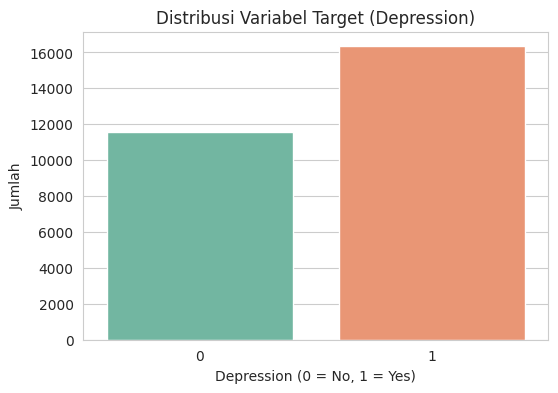

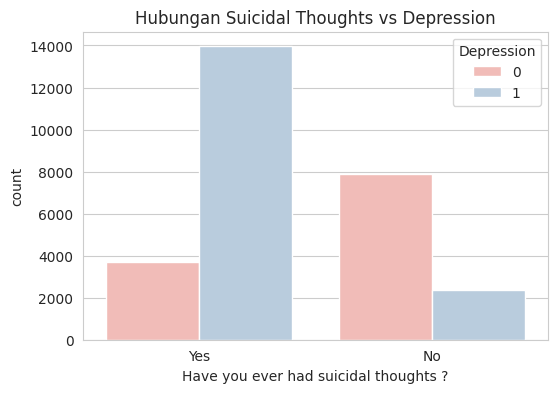

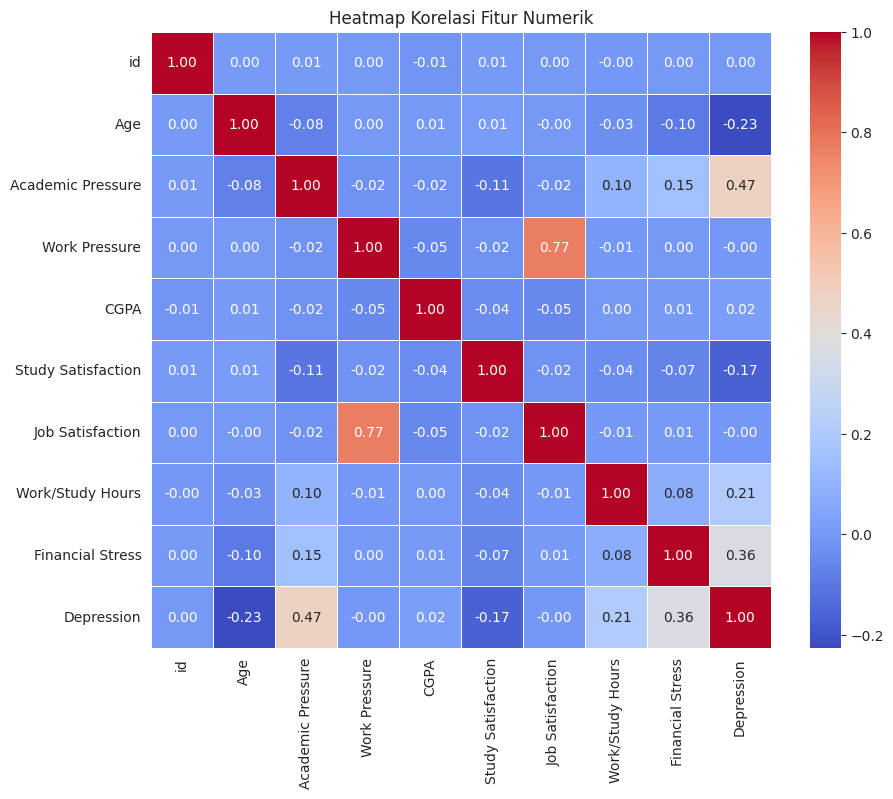

In [23]:
# 1. Visualisasi Distribusi Target Variable (Depression)
plt.figure(figsize=(6, 4))
sns.countplot(x='Depression', data=df, palette='Set2')
plt.title('Distribusi Variabel Target (Depression)')
plt.xlabel('Depression (0 = No, 1 = Yes)')
plt.ylabel('Jumlah')
plt.show()

# 2. Visualisasi Hubungan Antara Suicidal Thoughts dengan Depression
plt.figure(figsize=(6, 4))
sns.countplot(x='Have you ever had suicidal thoughts ?', hue='Depression', data=df, palette='Pastel1')
plt.title('Hubungan Suicidal Thoughts vs Depression')
plt.show()

# 3. Korelasi antar fitur numerik
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
# PERBAIKAN: Mengubah 'Coolwarm' menjadi 'coolwarm' (huruf kecil)
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

In [24]:
# 1. Menghapus kolom yang tidak relevan untuk modeling (seperti 'id' dan 'Profession' jika nilainya seragam)
columns_to_drop = ['id', 'Profession']
df_clean = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# 2. Encoding untuk kolom kategorikal menggunakan LabelEncoder
le = LabelEncoder()
categorical_cols = df_clean.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 3. Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['Depression'])
y = df_clean['Depression']

# 4. Split data menjadi Training Set (80%) dan Testing Set (20%)
# PERBAIKAN: Menggunakan test_size=0.2 (bukan test_test_split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Feature Scaling (Standardisasi fitur numerik agar skala datanya seragam)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Proses Data Preparation Selesai!")
print(f"Dimensi X_train: {X_train_scaled.shape}, Dimensi X_test: {X_test_scaled.shape}")

Proses Data Preparation Selesai!
Dimensi X_train: (22318, 15), Dimensi X_test: (5580, 15)


In [25]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Proses Training Model Selesai!")

Proses Training Model Selesai!


=== Evaluasi Model: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      2313
           1       0.86      0.88      0.87      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.84      0.84      5580



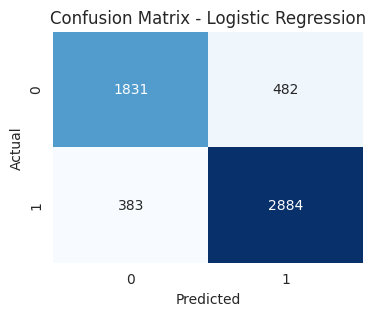

--------------------------------------------------
=== Evaluasi Model: Random Forest ===
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2313
           1       0.85      0.88      0.86      3267

    accuracy                           0.84      5580
   macro avg       0.83      0.83      0.83      5580
weighted avg       0.84      0.84      0.84      5580



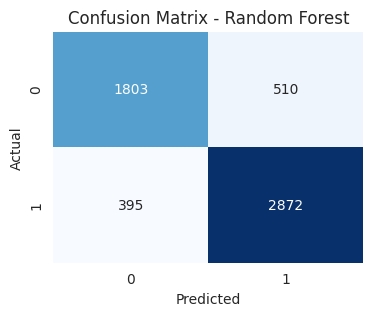

--------------------------------------------------


In [26]:
# Fungsi untuk menghitung dan menampilkan metrik evaluasi
def evaluate_model(y_true, y_pred, model_name):
    # Menggunakan average='macro' atau 'binary' sesuai target, default binary jika 0 dan 1
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"=== Evaluasi Model: {model_name} ===")
    print(classification_report(y_true, y_pred, zero_division=0))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print("-" * 50)

    return [acc, prec, rec, f1]

# Evaluasi kedua model
metrics_lr = evaluate_model(y_test, y_pred_lr, "Logistic Regression")
metrics_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")

=== Tabel Perbandingan Hasil Performa Model ===


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.844982,0.837814
1,Precision,0.856803,0.849202
2,Recall,0.882767,0.879094
3,F1-Score,0.869591,0.863889


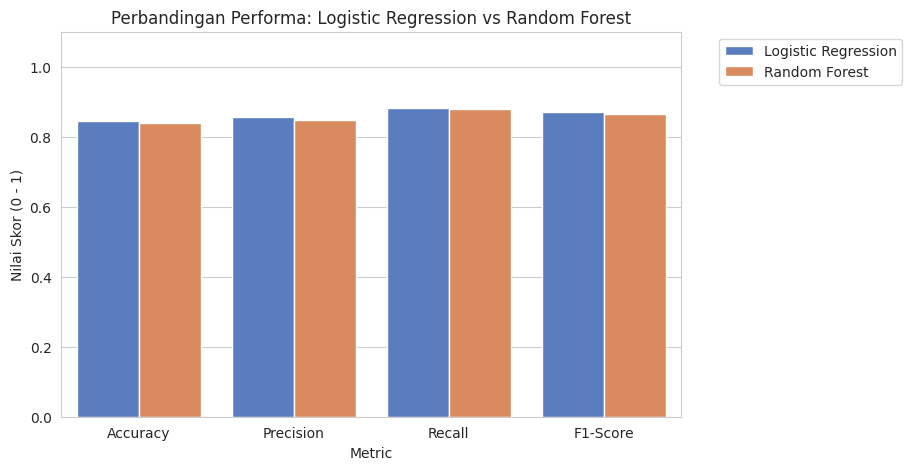

In [27]:
# Membuat dataframe perbandingan performa model
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': metrics_lr,
    'Random Forest': metrics_rf
})

# Menampilkan tabel perbandingan
print("=== Tabel Perbandingan Hasil Performa Model ===")
display(comparison_df)

# Visualisasi perbandingan akurasi
comparison_melted = pd.melt(comparison_df, id_vars=['Metric'], var_name='Model', value_name='Score')

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted, palette='muted')
plt.title('Perbandingan Performa: Logistic Regression vs Random Forest')
plt.ylim(0, 1.1)
plt.ylabel('Nilai Skor (0 - 1)')
# Memindahkan posisi legend agar tidak menutupi grafik
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [28]:
# === Bagian Tambahan: Query dan Analisis Data Spesifik ===

print("--- 1. Menampilkan Mahasiswa yang Mengalami Depresi (Depression = 1) ---")
# Memfilter data hanya untuk mahasiswa yang terindikasi mengalami depresi
data_depresi = df[df['Depression'] == 1]
print(f"Jumlah total mahasiswa yang depresi: {len(data_depresi)} orang")
# Menampilkan 5 baris pertama hasil filter
display(data_depresi.head())


print("\n--- 2. Menggunakan Fungsi .query() untuk Mencari Tekanan Finansial & Jam Kerja/Belajar Tinggi ---")
# Menyaring mahasiswa dengan Financial Stress berskala tinggi (>= 4) dan waktu belajar/kerja yang lama (> 6 jam)
# Menggunakan backtick (`) karena nama kolom memiliki spasi atau karakter khusus
hasil_query_stress = df.query("`Financial Stress` >= 4 and `Work/Study Hours` > 6")
print(f"Jumlah mahasiswa dengan tekanan finansial & jam belajar tinggi: {len(hasil_query_stress)} orang")
display(hasil_query_stress.head(3))


print("\n--- 3. Query Banyak Kondisi (Tekanan Akademik Maksimal & Pernah Terpikir Bunuh Diri) ---")
# Menyaring mahasiswa yang memiliki Academic Pressure bernilai maksimal (5.0) DAN menjawab 'Yes' pada kolom suicidal thoughts
kondisi_risiko = (df['Academic Pressure'] == 5.0) & (df['Have you ever had suicidal thoughts ?'] == 'Yes')
mahasiswa_risiko_tinggi = df[kondisi_risiko]

print(f"Jumlah mahasiswa risiko tinggi (Tekanan Akademik 5 & Ide Bunuh Diri 'Yes'): {len(mahasiswa_risiko_tinggi)} orang")
display(mahasiswa_risiko_tinggi[['Age', 'Gender', 'CGPA', 'Academic Pressure', 'Have you ever had suicidal thoughts ?']].head(5))


print("\n--- 4. Query Agregasi: Perbandingan Rata-Rata Faktor Berdasarkan Status Depresi ---")
# Menghitung rata-rata nilai IPK (CGPA), Tekanan Akademik, Tekanan Finansial, dan Jam Belajar
# antara kelompok yang depresi (1) dan tidak depresi (0)
kolom_analisis = ['Academic Pressure', 'Work/Study Hours', 'Financial Stress', 'CGPA']
rata_rata_per_kelompok = df.groupby('Depression')[kolom_analisis].mean()

print("Perbandingan Rata-Rata Faktor Risiko:")
display(rata_rata_per_kelompok)

--- 1. Menampilkan Mahasiswa yang Mengalami Depresi (Depression = 1) ---
Jumlah total mahasiswa yang depresi: 16335 orang


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,7-8 hours,Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,Less than 5 hours,Moderate,LLB,Yes,2.0,5.0,No,1
10,83,Male,24.0,Nagpur,Student,3.0,0.0,6.10,3.0,0.0,5-6 hours,Moderate,Class 12,Yes,11.0,1.0,Yes,1



--- 2. Menggunakan Fungsi .query() untuk Mencari Tekanan Finansial & Jam Kerja/Belajar Tinggi ---
Jumlah mahasiswa dengan tekanan finansial & jam belajar tinggi: 7882 orang


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
22,166,Female,25.0,Ahmedabad,Student,3.0,0.0,5.57,3.0,0.0,More than 8 hours,Unhealthy,MSc,Yes,10.0,5.0,No,1
24,173,Male,18.0,Bangalore,Student,4.0,0.0,7.10,3.0,0.0,More than 8 hours,Unhealthy,Class 12,Yes,11.0,5.0,Yes,1
27,193,Male,25.0,Lucknow,Student,3.0,0.0,7.25,3.0,0.0,More than 8 hours,Unhealthy,M.Ed,Yes,10.0,5.0,No,1



--- 3. Query Banyak Kondisi (Tekanan Akademik Maksimal & Pernah Terpikir Bunuh Diri) ---
Jumlah mahasiswa risiko tinggi (Tekanan Akademik 5 & Ide Bunuh Diri 'Yes'): 4841 orang


,Age,Gender,CGPA,Academic Pressure,Have you ever had suicidal thoughts ?
0,33.0,Male,8.97,5.0,Yes
14,19.0,Female,5.64,5.0,Yes
16,25.0,Male,6.51,5.0,Yes
17,20.0,Female,7.25,5.0,Yes
36,21.0,Female,9.72,5.0,Yes



--- 4. Query Agregasi: Perbandingan Rata-Rata Faktor Berdasarkan Status Depresi ---
Perbandingan Rata-Rata Faktor Risiko:


,Academic Pressure,Work/Study Hours,Financial Stress,CGPA
Depression,,,,
0,2.361757,6.237222,2.518724,7.617236
1,3.693174,7.807346,3.579553,7.683713
